# REGRESSION MASTER NOTEBOOK

REGRESSION MASTER NOTEBOOK
Hey! In this notebook, I have covered regression techniques in detail. I explained the theoretical information about regression techniques, evaluation metrics and bias-variance tradeoff, which is one of the important issues of regression. I tried to explain each technique with different datasets. Three different datasets are used in this notebook:

In each main topic, I used the same template:

In addition, in the Linear Regression section, I gave theoretical information about the metrics used in the evaluation of regression models, as well as coding.

# Before starting:¶
Main headings are indicated with a black background.
The following color palettes are used for each main title.

Headers Color:



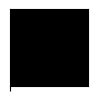

In [1]:
import seaborn as sns
headers = ['#000000']
print("Headers Color:")
sns.palplot(sns.color_palette(headers))
print()

Linear Regression Colors:



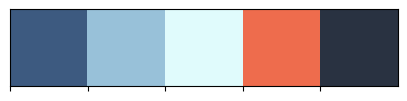

In [2]:
l_r = ['#3d5a80', '#98c1d9', '#e0fbfc', '#ee6c4d', '#293241']
print("Linear Regression Colors:")
sns.palplot(sns.color_palette(l_r))
print()

Multiple Linear Regression Colors:



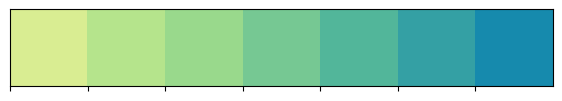

In [3]:
m_l_r = ['#d9ed92', '#b5e48c', '#99d98c', '#76c893', '#52b69a', '#34a0a4', '#168aad']
print("Multiple Linear Regression Colors:")
sns.palplot(sns.color_palette(m_l_r))
print()

Polynomial Regression Colors:



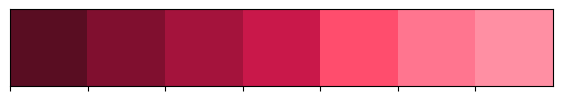

In [4]:
p_r = ['#590d22', '#800f2f', '#a4133c', '#c9184a', '#ff4d6d', '#ff758f', '#ff8fa3']
print("Polynomial Regression Colors:")
sns.palplot(sns.color_palette(p_r))
print()

Bias-Variance Tradeoff Colors:



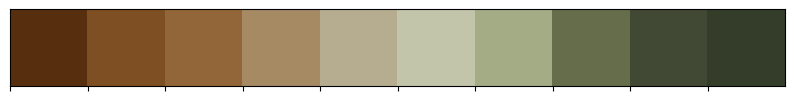

In [5]:
b_v_t = ['#582f0e', '#7f4f24', '#936639', '#a68a64', '#b6ad90', '#c2c5aa', '#a4ac86', '#656d4a', '#414833', '#333d29']
print("Bias-Variance Tradeoff Colors:")
sns.palplot(sns.color_palette(b_v_t))
print()

# Simple Linear Regression

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
%matplotlib inline





# Information About Dataset

In [2]:
df = pd.read_csv('IceCreamData.csv')
df.sample(10)

,Temperature,Revenue
76,40.473989,918.391232
415,20.016384,477.315188
129,32.297331,751.054570
261,23.577113,570.990932
295,17.588372,412.065001
42,18.775358,421.621505
300,5.858454,170.237756
70,12.688430,276.787086
246,25.422947,583.759781
353,24.528853,594.110352


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [4]:
df.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


# Data Visualization

<Figure size 1280x960 with 0 Axes>

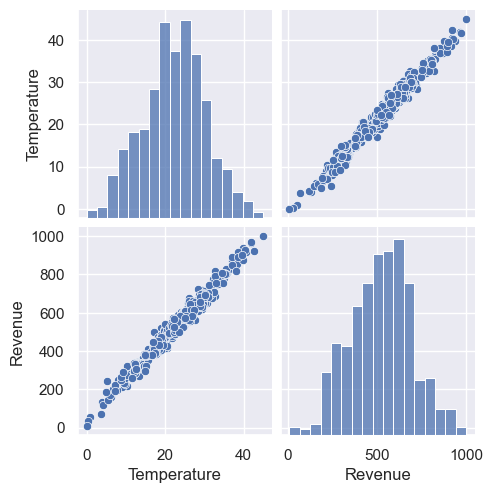

In [5]:
plt.figure(dpi = (200))
sns.pairplot(df)

<Figure size 640x480 with 0 Axes>

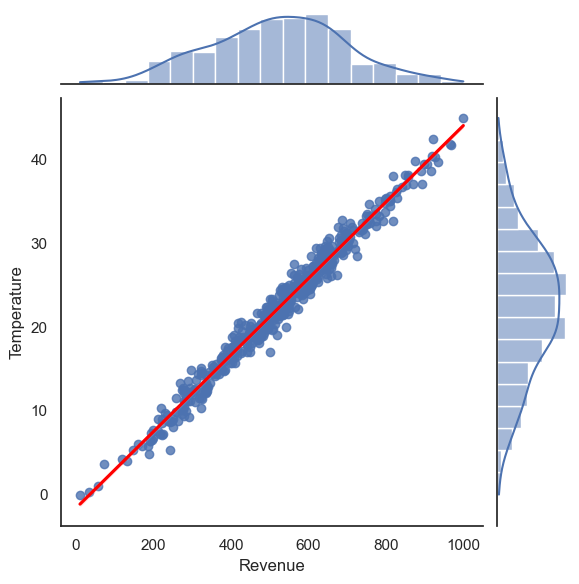

In [6]:
sns.set_theme(style="white")
plt.figure(dpi = (100))
sns.jointplot(x = df['Revenue'], y = df['Temperature'], kind='reg', line_kws={"color": "red"})

<Axes: xlabel='Revenue', ylabel='Temperature'>

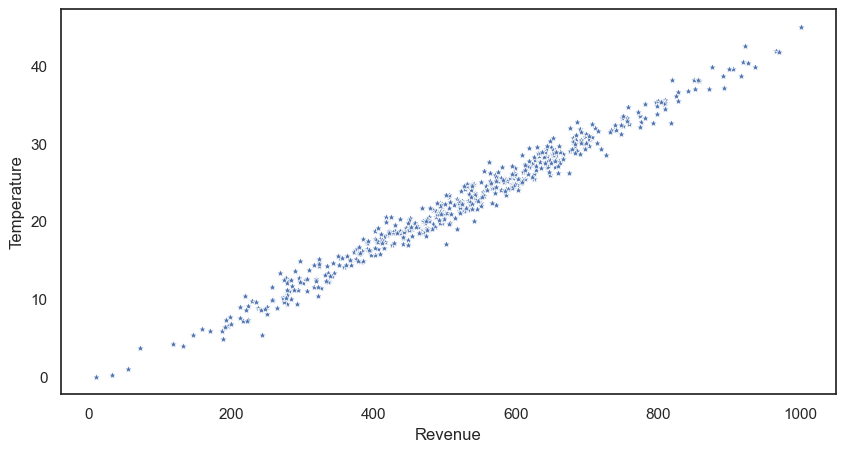

In [7]:
plt.figure(figsize = (10,5), dpi = (100))
sns.scatterplot(x = df['Revenue'], y = df['Temperature'], marker="*")

# Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = df[['Temperature']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 101)

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(X_test)}')
print(f'Shape of X_test: {X_test.shape}')

Total # of sample in whole dataset: 500
**************************************************
Total # of sample in train dataset: 335
Shape of X_train: (335, 1)
**************************************************
Total # of sample in test dataset: 165
Shape of X_test: (165, 1)


# Linear Regression

fit_intercept : bool, default=True Whether to calculate the intercept for this model. If set to False, no intercept will be used in calculations (i.e. data is expected to be centered).

normalize : bool, default=False This parameter is ignored when fit_intercept is set to False. If True, the regressors X will be normalized before regression by subtracting the mean and dividing by the l2-norm. If you wish to standardize, please use StandardScaler before calling fit on an estimator with normalize=False.

copy_X : bool, default=True If True, X will be copied; else, it may be overwritten.

n_jobs : int, default=None The number of jobs to use for the computation. This will only provide speedup for n_targets > 1 and sufficient large problems. None means 1 unless in a joblib.parallel_backend context. -1 means using all processors.

positive : bool, default=False When set to True, forces the coefficients to be positive. This option is only supported for dense arrays.

In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept = True)

METHOD : fit(X, y[, sample_weight]) --> It fits linear model.

X : {array-like, sparse matrix} of shape (n_samples, n_features)

Training data.

y :array-like of shape (n_samples,) or (n_samples, n_targets)

Target values. Will be cast to X’s dtype if necessary

sample_weight : array-like of shape (n_samples,), default=None

Individual weights for each sample

returns : self : returns an instance of self.

In [10]:
model.fit(X_train, y_train)

LinearRegression()

METHOD : predict(X, y[, sample_weight]) --> Predicts test values using the linear model.

X : array-like or sparse matrix, shape (n_samples, n_features)

Test samples.

returns : C --> array, shape (n_samples,)

It returns predicted values.

In [11]:
pred = model.predict(X_test)

METHOD : score(X, y[, sample_weight]) --> Return the coefficient of determination  R2
  of the prediction.

X : array-like of shape (n_samples, n_features)

Test samples. For some estimators this may be a precomputed kernel matrix or a list of generic objects instead with shape (n_samples, n_samples_fitted), where n_samples_fitted is the number of samples used in the fitting for the estimator.

y : array-like of shape (n_samples,) or (n_samples, n_outputs)

True values for X.

returns : score --> float

R2
  of self.predict(X) wrt. y.

In [12]:
train_score = model.score(X_train, y_train)
print(f'Train score of trained model: {train_score*100}')

test_score = model.score(X_test, y_test)
print(f'Test score of trained model: {test_score*100}')

Train score of trained model: 97.86733638283377
Test score of trained model: 98.18365687594093


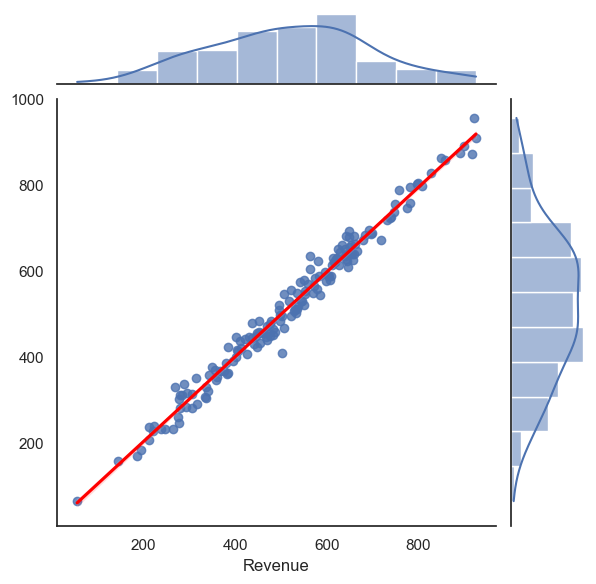

In [13]:
sns.set_theme(style="white")
sns.jointplot(x=y_test, y=pred, kind='reg', line_kws={"color": "red"})

# Evaluation of Model

# Mean Squared Error
Mean Square Error (MSE) is the most commonly used regression loss function. MSE is the average loss of frames per sample across the entire dataset. To calculate the MSE, sum all frame losses for individual samples and then divide by the number of samples. 
 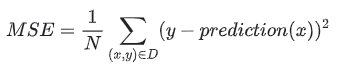

In [14]:
from sklearn.metrics import mean_squared_error
print("Mean Squared Error:",mean_squared_error(y_test, pred))

Mean Squared Error: 549.2134978280797


# Root Mean Squared Error
It is a quadratic metric that measures the magnitude of the error, often used to find the distance between the predictor's predicted values and the actual values of a machine learning model. The standard deviation of the RMSE estimation errors (residues). That is, the residuals are a measure of how far the regression line is from the data points; RMSE is a measure of how far these residues spread. In other words, it tells you how dense that data is around the line that best fits the data. The RMSE value can range from 0 to infinity. Negative oriented scores, i.e. predictors with lower values, perform better. A zero RMSE value means the model made no mistakes. RMSE has the advantage of punishing large errors more so it may be better suited to some situations. RMSE prevents the unwanted use of absolute values in many mathematical calculations.

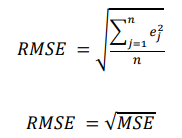

In [15]:
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test, pred)))

Root Mean Squared Error: 23.43530451750264


# Mean Absolute Error
Absolute error is the difference between estimated values and actual values. To be exact, it is the mean of the absolute value of each difference between the actual value and the predicted value for that sample across the entire sample of the data set.

.y is the true value.
.y^ is the predicted value.
A lower value indicates better accuracy. 
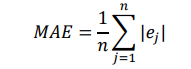

In [16]:
from sklearn.metrics import mean_absolute_error
print("Mean Absolute Error:",mean_absolute_error(y_test, pred))

Mean Absolute Error: 18.723628423305314


# Mean Absolute Percentage Error
In regression and time series models, mean absolute percent error is frequently used to measure the accuracy of predictions. If there are zero among the real values, the MAPE cannot be calculated as there will be division by zero. Percentage error cannot exceed 100% for very low predictive values, but there is no upper limit for the percentage error for very high predictive values. When MAPE is used to compare the accuracy of estimators, it is biased as it systematically selects a method that is too low for estimates. This small but serious problem can be overcome with an accuracy criterion that finds the ratio of predicted values to their true values. This approach leads to estimates that can be interpreted in terms of the geometric mean. 

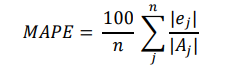

In [17]:
import sklearn.metrics as m
print("Mean Absolute Percentage Error:",np.mean(np.abs( (y_test-pred) / y_test))*100)

Mean Absolute Percentage Error: 4.210864067222878


# R square
R² is a statistical measure of how close the data are to the fitted regression line. It is also known as the coefficient of determination or the multiple coefficient of determination for multiple regression. To put it in simpler language, R-square is a measure of fit for linear regression models.

R-squared does not indicate whether a regression model fits your data adequately. A good model can have a low R-squared value. On the other hand, a biased model can have a high R-squared value! 
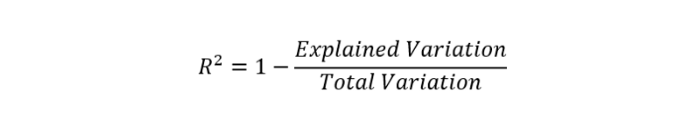

In [18]:
from sklearn.metrics import r2_score
print("R^2:",r2_score(y_test, pred))

R^2: 0.9818365687594093


# Adjusted R Squared
Each additional argument added to a model always increases the R² value.

As the independent variable is added, the model becomes more complex, when the model becomes complex, "overfitting" occurs. Hence R-squared increases.

Adjusted R-square comes into play to solve such problems. The adjusted R-square compensates for each independent variable and only increases when each given variable improves the model above what is possible.  

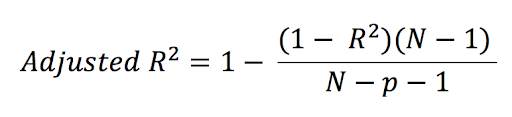

In [19]:
import sklearn.metrics as m
n=X_test.shape[0]
p=X_test.shape[1] - 1
R2 = m.r2_score(y_test, pred)

adj_rsquared = 1 - (1 - R2) * ((n - 1)/(n-p-1))
print('Adjusted R Squared: {}'.format(adj_rsquared))

Adjusted R Squared: 0.9818365687594093


Let's put it all together

In [20]:
import sklearn.metrics as metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from math import sqrt

k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
MAPE = np.mean(np.abs( (y_test-pred) / y_test))*100
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

In [21]:
results = [MSE, RMSE, MAE, MAPE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'MAPE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,549.213498
1,RMSE,23.435305
2,MAE,18.723628
3,MAPE,4.210864
4,r2,0.981837
5,adj_r2,0.981725
